<a href="https://colab.research.google.com/github/chandana-musunuru/MachineLearning/blob/gradIndependentStudy/grad%20independent%20study/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle


In [2]:
from google.colab import files
files.upload()  # This will prompt you to upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chapradeepthi","key":"7888b69723b0be99c8212cbceba0faeb"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d suchintikasarkar/sentiment-analysis-for-mental-health


Dataset URL: https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health
License(s): DbCL-1.0


In [5]:
!unzip sentiment-analysis-for-mental-health.zip -d ./dataset
!ls ./dataset
import pandas as pd


df = pd.read_csv("./dataset/Combined Data.csv")

# Display the first few rows
df.head()


Archive:  sentiment-analysis-for-mental-health.zip
  inflating: ./dataset/Combined Data.csv  
'Combined Data.csv'


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [6]:

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [7]:
#data cleaning

In [8]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 0


In [9]:
print(df.head())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety


In [10]:

# Remove the 'Unnamed' columns if they exist
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Display the cleaned DataFrame
print(df.head())

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3  I've shifted my focus to something else but I'...  Anxiety
4  I'm restless and restless, it's been a month n...  Anxiety


In [11]:
import nltk
import os
import re


nltk.data.path.append("/usr/local/nltk_data")  # Ensure NLTK searches this directory
nltk.download('punkt', download_dir="/usr/local/nltk_data")
nltk.download('punkt_tab')
nltk.download('stopwords', download_dir="/usr/local/nltk_data")
nltk.download('wordnet', download_dir="/usr/local/nltk_data")
print(os.listdir("/usr/local/nltk_data/tokenizers"))

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer



stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if isinstance(text, str):  # Check if text is a string
        text = text.lower()
        text = re.sub(r'http\S+', '', text)  # Remove URLs
        text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special chars
        words = word_tokenize(text)
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return " ".join(words)
    return ""  # Return empty string if the text is not a string

df["cleaned_statement"] = df["statement"].apply(clean_text)


[nltk_data] Downloading package punkt to /usr/local/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /usr/local/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /usr/local/nltk_data...


['punkt', 'punkt.zip']


In [12]:
df = df.dropna(subset=["cleaned_statement"])
df = df[df["cleaned_statement"].str.strip() != ""]



In [13]:
print(df.describe())

                statement  status cleaned_statement
count               52546   52546             52546
unique              50991       7             50493
top     what do you mean?  Normal               yes
freq                   22   16213                25


In [14]:
print("Number of duplicate rows after dropping::", df.duplicated().sum())

Number of duplicate rows after dropping:: 1535


In [15]:
# Now you can drop duplicates as needed
df_cleaned = df.drop_duplicates(subset=["cleaned_statement", "status"], keep="first")


# Select only the cleaned_statement and status columns for visualization
df_cleaned = df_cleaned[["cleaned_statement", "status"]]

# Print the cleaned DataFrame with both columns side by side
print(df_cleaned)

                                       cleaned_statement   status
0                                                oh gosh  Anxiety
1      trouble sleeping confused mind restless heart ...  Anxiety
2      wrong back dear forward doubt stay restless re...  Anxiety
3      ive shifted focus something else im still worried  Anxiety
4                    im restless restless month boy mean  Anxiety
...                                                  ...      ...
52835  anxiety cause faintness standing title anxiety...  Anxiety
52836  anxiety heart symptom anyone else something si...  Anxiety
52837  travel anxiety hi long time anxiety sufferer f...  Anxiety
52839  fomo thing im involved anyone else get recentl...  Anxiety
52840  getting day get anything done anxiety keep hou...  Anxiety

[50536 rows x 2 columns]


In [16]:
# Check for duplicates after dropping them
duplicates_after_cleaning = df_cleaned.duplicated(subset=["cleaned_statement", "status"]).sum()

print(f"Number of duplicates after cleaning: {duplicates_after_cleaning}")


Number of duplicates after cleaning: 0


In [17]:
# Group by 'cleaned_statement' and 'status', then count the occurrences
top_duplicates = df_cleaned.groupby(["cleaned_statement", "status"]).size().reset_index(name="count")

# Sort by count to get the most frequent ones
top_duplicates_sorted = top_duplicates.sort_values(by="count", ascending=False)

# Display top 3 frequent combinations
print(top_duplicates_sorted.head(20))


                                       cleaned_statement  \
50535         zzzzzzzzz georgina calahara cascavel piaui   
0                                      aaa dreamies cool   
1                                 aaa impatient dreamies   
2      aaa lot hobby hair breast open button shirt ne...   
3                                aaa next account locked   
4                                     aaa today mv dream   
5       aaaa im ashamed fall motorbike doesnt hurt shame   
6                           aaaa im proud going dreamies   
50519  zoloft hi prescribed zoloft month treat depres...   
50518  zoloft help used zoloft day month ago didnt fe...   
50517  zoloft focalin changed life past four year bet...   
50516  zoloft day doctor added mg endep ontop anxiety...   
50515  zoloft buspar anyone else combination got pres...   
50514  zoeaimee trying research dude english assignme...   
50513  zinziii dammit ya heading home get messy drunk...   
50512                     zerohedge depr

In [18]:
# Filter to display only combinations that appear more than once
top_duplicates_filtered = top_duplicates_sorted[top_duplicates_sorted['count'] > 1]

# Display filtered results
print(top_duplicates_filtered)


Empty DataFrame
Columns: [cleaned_statement, status, count]
Index: []


In [19]:
#data visulaization cleaned_statement", "status"

In [20]:
unique_status_values = df_cleaned['status'].unique()
print(unique_status_values)

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


In [21]:
print(df_cleaned.head())

                                   cleaned_statement   status
0                                            oh gosh  Anxiety
1  trouble sleeping confused mind restless heart ...  Anxiety
2  wrong back dear forward doubt stay restless re...  Anxiety
3  ive shifted focus something else im still worried  Anxiety
4                im restless restless month boy mean  Anxiety


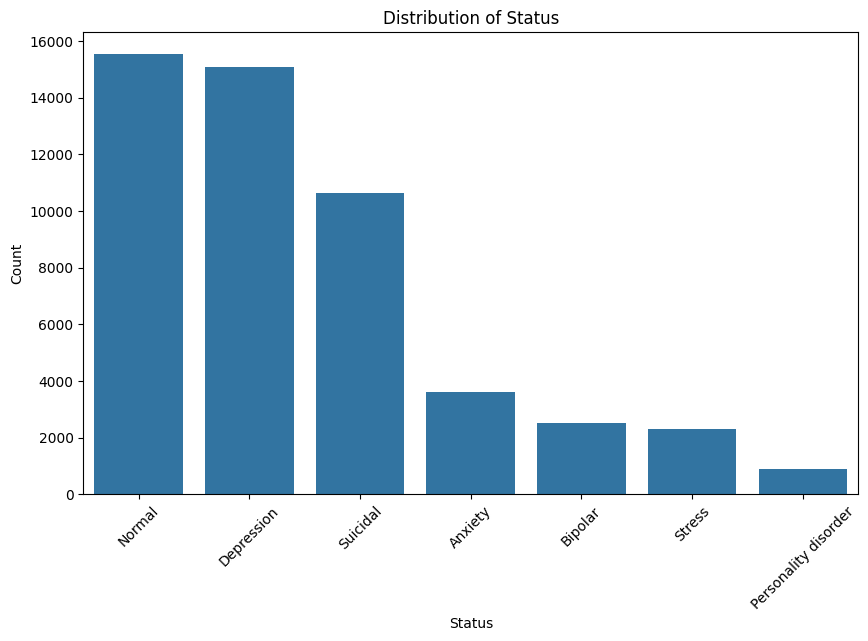

In [22]:
#distribution of different categories in the status column to see the frequency of each status.
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each status
status_counts = df_cleaned['status'].value_counts()

# Plotting the distribution of status
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title("Distribution of Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


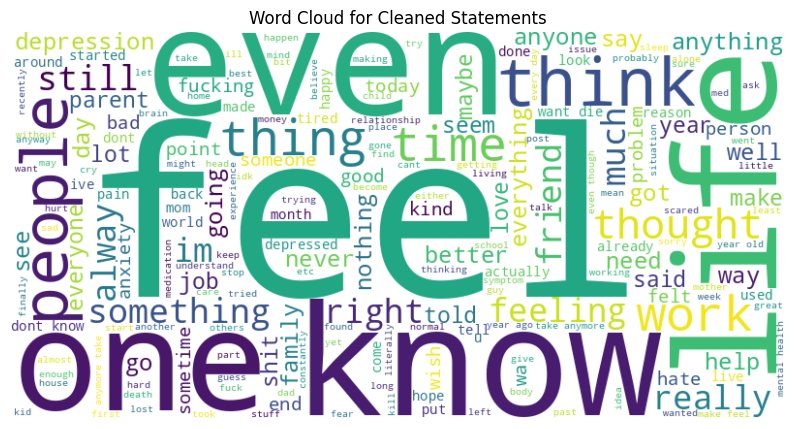

In [23]:
#A word cloud can visually represent the most frequently used words in the cleaned_statement column. It's useful for text analysis
from wordcloud import WordCloud

# Generate the word cloud for cleaned statements
text = ' '.join(df_cleaned['cleaned_statement'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Cleaned Statements')
plt.show()


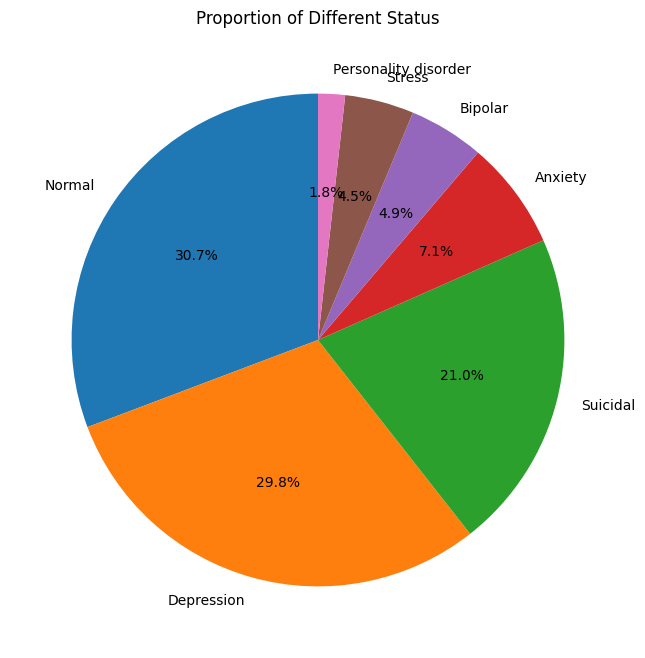

In [24]:
# Pie chart for status distribution
status_counts = df_cleaned['status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Different Status')
plt.show()


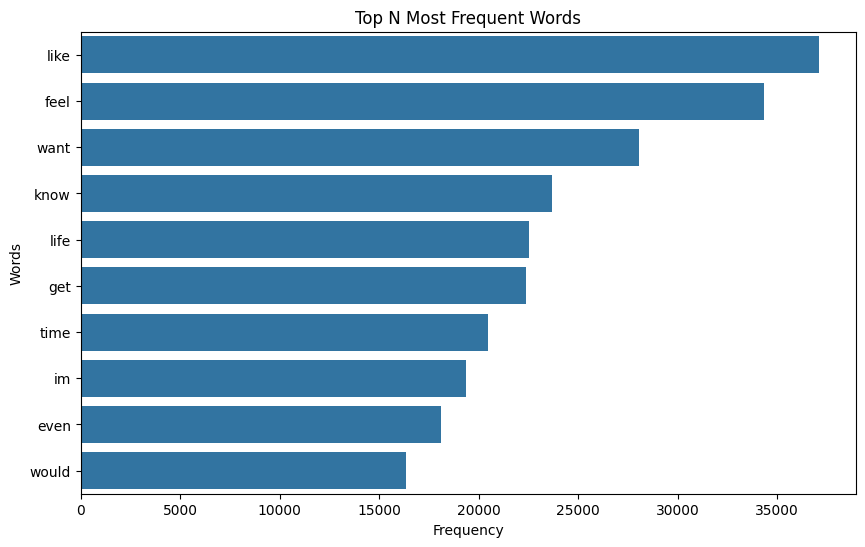

In [25]:
from collections import Counter

# Get word frequency distribution
all_words = ' '.join(df_cleaned['cleaned_statement']).split()
word_freq = Counter(all_words)

# Get top N most common words
top_words = word_freq.most_common(10)

# Plotting the top N frequent words
words, freq = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=freq, y=words)
plt.title("Top N Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


In [26]:
print(df_cleaned.describe())

       cleaned_statement  status
count              50536   50536
unique             50493       7
top                 name  Normal
freq                   4   15539


In [27]:
print(df_cleaned.columns)


Index(['cleaned_statement', 'status'], dtype='object')


In [28]:
#data preprocessing
#1)label encoding

In [29]:
import pandas as pd
import nltk
nltk.download('vader_lexicon')
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer


sid = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    sentiment_scores = sid.polarity_scores(text)
    return sentiment_scores['compound']  # Compound score (overall sentiment)

# Add sentiment score as a new column
df_cleaned['sentiment_score'] = df_cleaned['cleaned_statement'].apply(get_sentiment_score)

# Check shape before any transformation
print(f"Initial shape of df_cleaned: {df_cleaned.shape}")

# Apply One-Hot Encoding to 'status' column
df_cleaned = pd.get_dummies(df_cleaned, columns=['status'], drop_first=False)
print(f"Shape after one-hot encoding: {df_cleaned.shape}")

print(f"Missing values in cleaned_statement: {df_cleaned['cleaned_statement'].isnull().sum()}")
print(f"Missing values insentiment_score: {df_cleaned['sentiment_score'].isnull().sum()}")

print(f"Duplicate cleaned_statement rows: {df_cleaned.duplicated(subset=['cleaned_statement']).sum()}")
print(f"Shape of df_cleaned before TF-IDF: {df_cleaned.shape}")
print(f"Missing values in cleaned_statement: {df_cleaned['cleaned_statement'].isnull().sum()}")



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Initial shape of df_cleaned: (50536, 3)
Shape after one-hot encoding: (50536, 9)
Missing values in cleaned_statement: 0
Missing values insentiment_score: 0
Duplicate cleaned_statement rows: 43
Shape of df_cleaned before TF-IDF: (50536, 9)
Missing values in cleaned_statement: 0


In [30]:
print(df_cleaned.head())

                                   cleaned_statement  sentiment_score  \
0                                            oh gosh           0.0000   
1  trouble sleeping confused mind restless heart ...          -0.7269   
2  wrong back dear forward doubt stay restless re...          -0.7351   
3  ive shifted focus something else im still worried          -0.2960   
4                im restless restless month boy mean          -0.4939   

   status_Anxiety  status_Bipolar  status_Depression  status_Normal  \
0            True           False              False          False   
1            True           False              False          False   
2            True           False              False          False   
3            True           False              False          False   
4            True           False              False          False   

   status_Personality disorder  status_Stress  status_Suicidal  
0                        False          False            False  
1   

In [31]:
print(f"Shape after One-Hot Encoding: {df_cleaned.shape}")

Shape after One-Hot Encoding: (50536, 9)


In [32]:
print("hello")

hello


In [33]:
import pandas as pd
import numpy as np
import nltk
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import DistilBertTokenizer, DistilBertModel
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Download vader lexicon for sentiment analysis
nltk.download('vader_lexicon')


# Load DistilBERT Tokenizer and Model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# Function to encode text using DistilBERT
def encode_text(texts, tokenizer, max_length=128):
    encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=max_length, return_tensors='pt')
    return encodings['input_ids'], encodings['attention_mask']

# Encode the cleaned_statement text data
X_input_ids, X_attention_mask = encode_text(df_cleaned['cleaned_statement'], tokenizer)

# Extract sentiment scores as numpy array
X_sentiment_scores = df_cleaned[['sentiment_score']].values

# Combine the embeddings with the sentiment scores
X_combined = torch.cat((X_input_ids, X_attention_mask, torch.tensor(X_sentiment_scores, dtype=torch.float32)), dim=1)

# Target labels (One-Hot Encoding for multi-label classification)
y = df_cleaned.drop(columns=['cleaned_statement', 'sentiment_score']).values

# Apply SMOTE to handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined.numpy(), y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Convert to Torch Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader for batching
train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

# Define a simple neural network for classification
class DistilBERT_Classifier(nn.Module):
    def __init__(self):
        super(DistilBERT_Classifier, self).__init__()
        self.distilbert = distilbert_model
        self.fc = nn.Linear(768 + 1, 7)  # 768 for DistilBERT embedding + 1 for sentiment score, 7 output labels

    def forward(self, input_ids, attention_mask, sentiment_score):
        distilbert_output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = distilbert_output.last_hidden_state[:, 0, :]  # Use the [CLS] token representation
        combined_input = torch.cat((pooled_output, sentiment_score), dim=1)  # Concatenate sentiment score
        output = self.fc(combined_input)
        return output

# Initialize the model, loss function, and optimizer
model = DistilBERT_Classifier()
criterion = nn.BCEWithLogitsLoss()  # Binary Cross-Entropy for multi-label classification
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)




[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# Rebuild the TensorDataset with proper structure:
train_data = TensorDataset(X_train_tensor[:, :-1].long(), X_train_tensor[:, :-1].long(), X_train_tensor[:, -1:].float(), y_train_tensor.float())  # Exclude sentiment score and target labels correctly
test_data = TensorDataset(X_test_tensor[:, :-1].long(), X_test_tensor[:, :-1].long(), X_test_tensor[:, -1:].float(), y_test_tensor.float())  # Same for test data

# Custom collate_fn to return batches correctly
def collate_fn(batch):
    input_ids = torch.stack([item[0] for item in batch])  # Stack input_ids from the batch
    attention_mask = torch.stack([item[1] for item in batch])  # Stack attention_mask from the batch
    sentiment_score = torch.stack([item[2] for item in batch])  # Stack sentiment scores from the batch
    labels = torch.stack([item[3] for item in batch])  # Stack labels from the batch
    return input_ids, attention_mask, sentiment_score, labels

# Update DataLoader to use the correct collate function
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False, collate_fn=collate_fn)

# Training Loop
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids, attention_mask, sentiment_score, labels = batch
        optimizer.zero_grad()

        # Ensure the input dimensions are correct
        outputs = model(input_ids, attention_mask, sentiment_score)

        # Compute the loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(train_loader)}")

# Evaluate the model on the test set
model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, sentiment_score, labels = batch
        outputs = model(input_ids, attention_mask, sentiment_score)
        predictions.append(outputs)

# Convert predictions to probabilities using sigmoid
predictions = torch.sigmoid(torch.cat(predictions))


In [ ]:
# Check for missing values in the dataset
print(df_cleaned.isnull().sum())


In [ ]:
print(df_cleaned.head())